In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

import tensorflow as tf
import tensorflow_datasets as tfds

In [43]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [44]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

In [45]:
class_names = [
'Cero','Uno','Dos','Tres','Cuatro',
'Cinco','Seis','Siete','Ocho','Nueve'
]

In [46]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

In [47]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [48]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [49]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [50]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [51]:
BATCHSIZE = 32

train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [52]:
history = model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE),
    validation_data=test_dataset,
    validation_steps=math.ceil(num_test_examples / BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9194 - loss: 0.2789 - val_accuracy: 0.9522 - val_loss: 0.1509
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9636 - loss: 0.1190 - val_accuracy: 0.9685 - val_loss: 0.1020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9733 - loss: 0.0896 - val_accuracy: 0.9686 - val_loss: 0.0950
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9791 - loss: 0.0689 - val_accuracy: 0.9668 - val_loss: 0.1027
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9818 - loss: 0.0571 - val_accuracy: 0.9701 - val_loss: 0.1015


In [53]:
test_loss, test_accuracy = model.evaluate(
test_dataset,
steps=math.ceil(num_test_examples/32)
)

print("Resultado en las pruebas:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.9701 - loss: 0.1015
Resultado en las pruebas: 0.9700999855995178


In [54]:
history

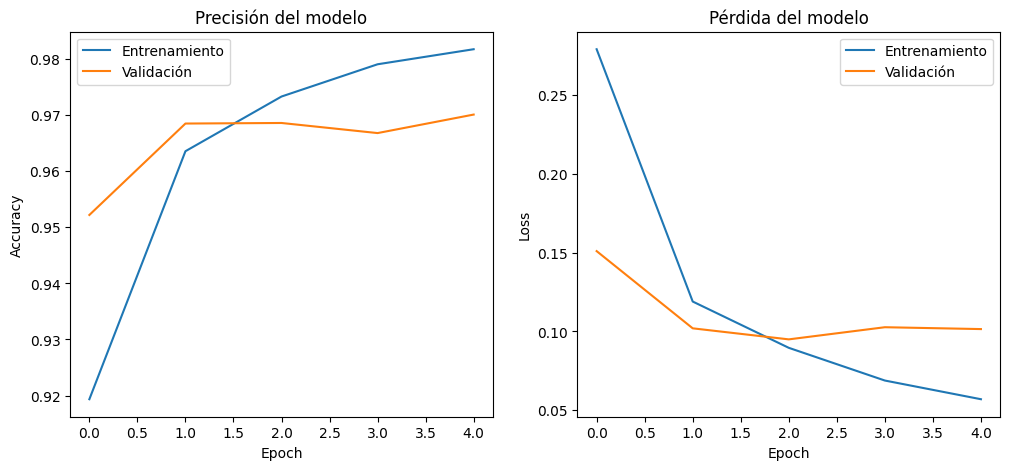

In [55]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


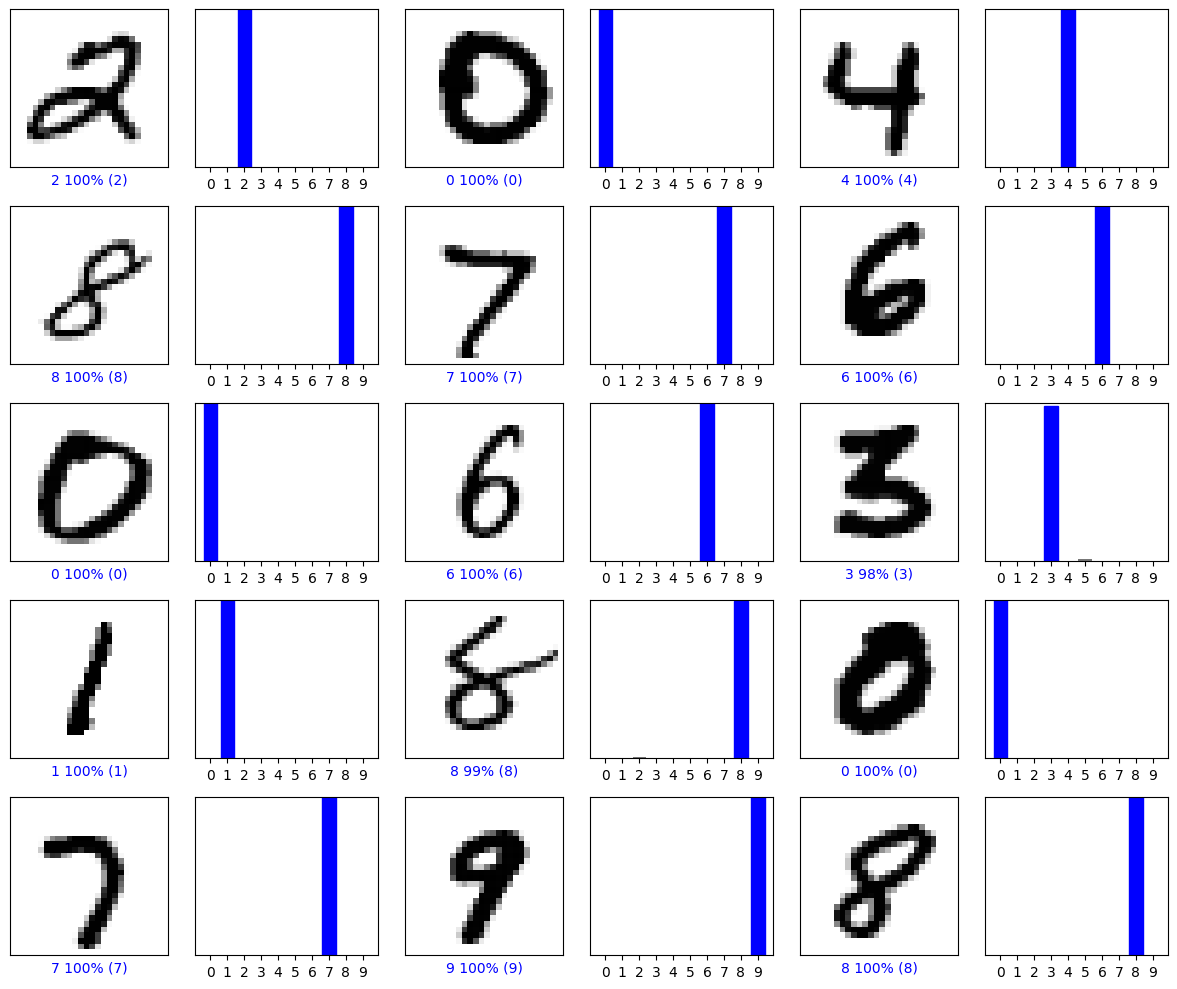

In [56]:
# Tomar un lote de imágenes de prueba
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()

predictions = model.predict(test_images)

# Función para mostrar imagen y predicción
def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)

    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(
        "{} {:2.0f}% ({})".format(
            predicted_label,
            100 * np.max(predictions_array),
            true_label
        ),
        color=color
    )

# Función para mostrar barras de probabilidad
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]

    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])

    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Mostrar varias predicciones
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)

    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()